In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import tensorflow as tf

model = tf.keras.models.load_model('/content/drive/MyDrive/Universidad/Investigacion/models/1.keras', compile=True)
dataset = tf.data.Dataset.load("/content/drive/MyDrive/Universidad/Investigacion/tf_datasets/test")

In [3]:
import numpy as np
dataset_features = dataset.map(lambda x, y: x)
y_pred_proba = model.predict(dataset_features)
yp = np.argmax(y_pred_proba, axis=1)

yt = np.concatenate([y.numpy() for _, y in dataset], axis=0)
yt = np.argmax(yt, axis=1)

310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step


                                                  precision    recall  f1-score   support

                                         Correct       0.91      0.98      0.94      1244
                                   Initial state       0.91      0.98      0.95      1265
                            Transformation State       0.92      0.93      0.92      1200
             Initial state, Transformation State       0.89      0.95      0.92      1233
                                     Final state       0.94      0.93      0.94      1227
                      Initial state, Final state       0.91      0.93      0.92      1209
               Final state, Transformation State       0.97      0.88      0.92      1248
Initial state, Final state, Transformation State       0.97      0.84      0.90      1274

                                        accuracy                           0.93      9900
                                       macro avg       0.93      0.93      0.93      9900
        

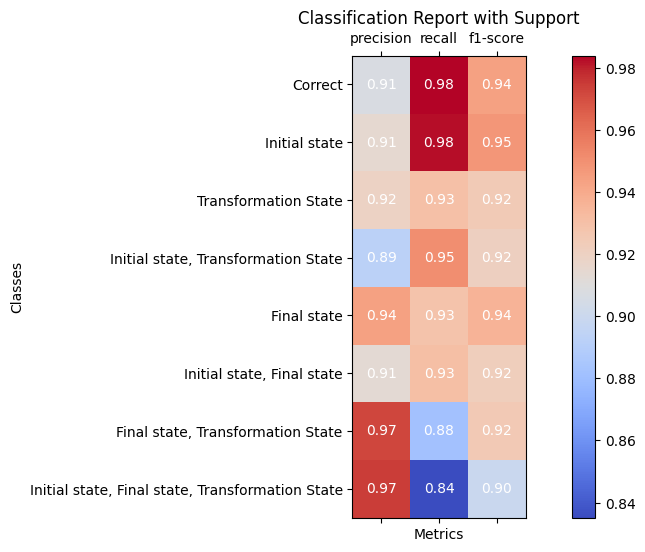

In [4]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

category=np.array([
    'Correct',
    'Initial state',
    'Transformation State',
    'Initial state, Transformation State',
    'Final state',
    'Initial state, Final state',
    'Final state, Transformation State',
    'Initial state, Final state, Transformation State'
])

def plot_classification_report_with_support(report):
    labels = list(report.keys())[:-3]
    metrics = ['precision', 'recall', 'f1-score']
    data = np.array([[report[label][metric] for metric in metrics] for label in labels])
    fig, ax = plt.subplots(figsize=(12, 6))
    cax = ax.matshow(data, cmap='coolwarm')
    plt.xticks(range(len(metrics)), metrics)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(cax)
    for (i, j), val in np.ndenumerate(data):
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white')
    plt.xlabel('Metrics')
    plt.ylabel('Classes')
    plt.title('Classification Report with Support')
    plt.show()

print(classification_report(yt,yp,target_names=category))
plot_classification_report_with_support(classification_report(yt,yp,target_names=category, output_dict=True))

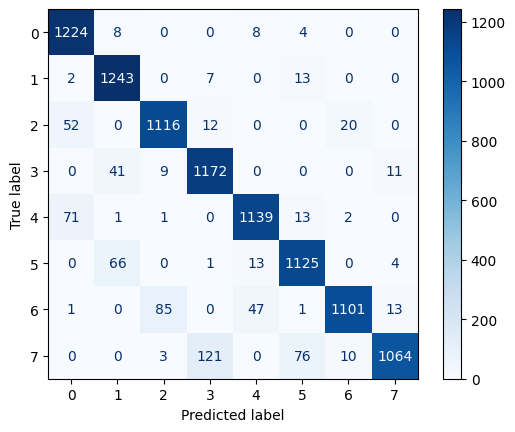

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(yt, yp)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)

cm_display.plot(cmap='Blues')
plt.show()

In [6]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(yt, yp)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

Matthews Correlation Coefficient (MCC): 0.9177


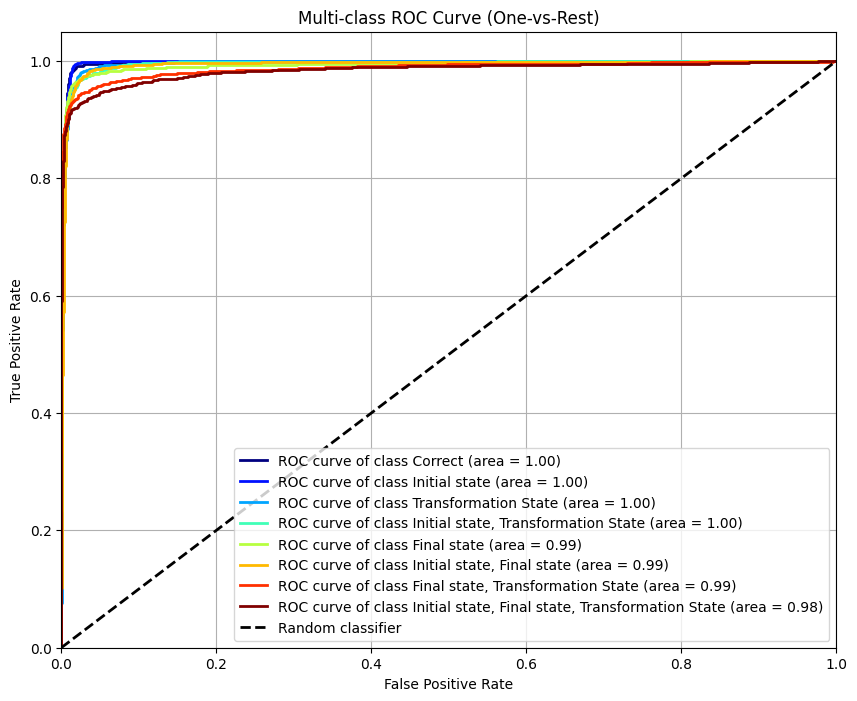

In [7]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

# Binarize the true labels for OvR strategy
label_binarizer = LabelBinarizer().fit(yt)
yt_onehot = label_binarizer.transform(yt)

# Number of classes
n_classes = len(category)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(yt_onehot[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.jet(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(category[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

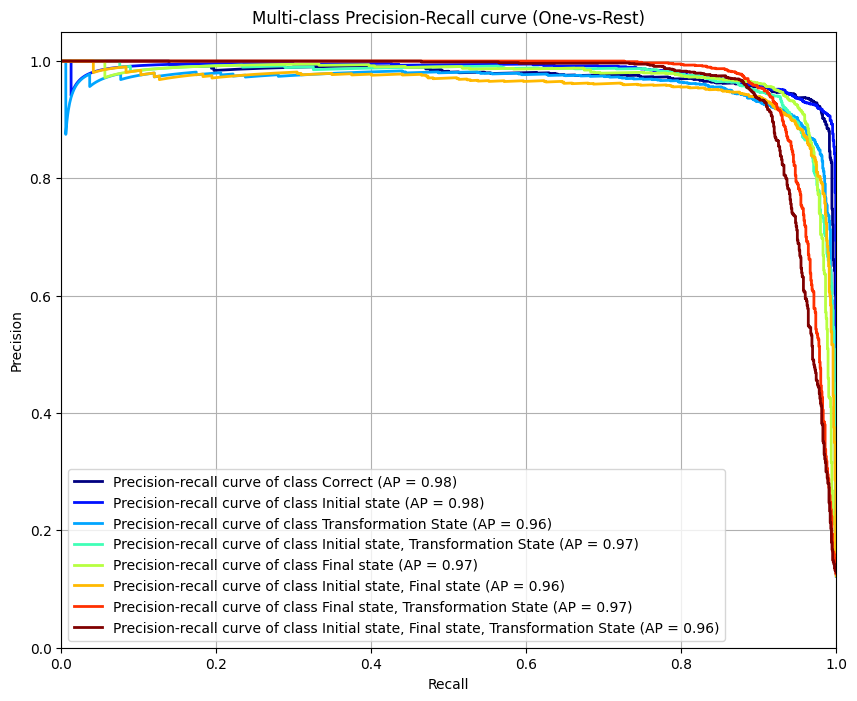

In [8]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt

# Number of classes
n_classes = len(category)

# Compute Precision-Recall curve and area for each class
precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(10, 8))
colors = plt.cm.jet(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    precision[i], recall[i], _ = precision_recall_curve(yt_onehot[:, i], y_pred_proba[:, i])
    average_precision[i] = average_precision_score(yt_onehot[:, i], y_pred_proba[:, i])

    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='Precision-recall curve of class {0} (AP = {1:0.2f})'
             ''.format(category[i], average_precision[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-class Precision-Recall curve (One-vs-Rest)')
plt.legend(loc='lower left')
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()